# English Premier League Stats (2021–2024)


Dataset Link: https://www.kaggle.com/datasets/mohamadsallah5/english-premier-league-stats20212024/data

Dalam notebook ini, kami akan mengkaji dataset yang merekam berbagai statistik pertandingan dari Liga Primer Inggris musim 2021-2024. Kumpulan data ini mencakup detail seperti tanggal pertandingan, stadion, jumlah penonton, metrik performa tim, dan lainnya. Tujuan kami adalah melakukan analisis data eksploratif (EDA) yang nantinya akan dibangun untuk model prediktif yang memperkirakan hasil pertandingan berdasarkan fitur-fitur tertentu.

# 1. Package

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# 2. Data

In [ ]:
path = kagglehub.dataset_download('mohamadsallah5/english-premier-league-stats20212024')

excel_path = os.path.join(path, 'mydata.csv')
df = pd.read_csv(excel_path)

df.sample(10)

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,away_on,home_off,away_off,home_blocked,away_blocked,home_pass,away_pass,home_chances,away_chances,home_corners,away_corners,home_offside,away_offside,home_tackles,away_tackles,home_duels,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
107,1st April 2023,3:00pm,Selhurst Park,h,"25,143",11,2,18,1,51.0,49.0,31,3,9,2,8,0,14,1,80.0,77.5,2,0,10,1,1,2,66.7,50.0,46.9,53.1,1,8,12,16,3,4,0,0,https://www.skysports.com/football/crystal-pal...
710,19th September 2021,4:30pm,Tottenham Hotspur Stadium,a,"60,059",8,0,12,3,47.0,53.0,8,20,2,10,4,3,2,7,82.3,87.0,1,3,5,11,0,1,60.0,53.3,40.0,60.0,6,2,4,15,0,1,0,0,https://www.skysports.com/football/tottenham-h...
161,12th February 2023,2:00pm,Elland Road,a,"36,919",19,0,3,2,33.0,67.0,16,11,6,5,4,4,6,2,67.7,81.6,1,2,7,3,3,3,56.5,70.0,57.1,42.9,3,6,10,13,2,1,0,0,https://www.skysports.com/football/leeds-unite...
177,4th February 2023,3:00pm,Old Trafford,h,"73,420",3,2,11,1,53.1,46.9,14,10,5,3,5,5,4,2,85.4,80.3,0,2,5,5,1,4,57.1,56.3,57.9,42.1,2,3,9,9,1,2,1,0,https://www.skysports.com/football/manchester-...
656,6th November 2021,3:00pm,Gtech Community Stadium,a,"16,837",9,1,22,2,64.5,35.5,19,9,7,5,5,3,7,1,77.8,67.4,3,0,6,2,2,3,73.7,43.8,60.3,39.7,4,6,12,13,2,3,0,0,https://www.skysports.com/football/brentford-v...
1016,16/12/2020,6:00pm,Elland Road,h,0,19,5,4,2,68.7,31.3,25,10,10,4,8,5,7,1,83.3,65.9,2,2,7,4,4,2,46.2,37.5,48.6,51.4,2,5,10,13,3,1,0,0,https://www.skysports.com/football/leeds-unite...
765,23/05/2021,4:00pm,The King Power Stadium,a,0,18,2,8,4,47.0,53.0,10,11,6,4,2,2,2,5,76.6,80.7,0,0,8,7,3,1,60.7,72.2,40.7,59.3,1,4,9,8,0,2,0,0,https://www.skysports.com/football/leicester-c...
1050,23/11/2020,8:00pm,Molineux,d,0,13,1,20,1,45.3,54.7,20,7,9,2,5,3,6,2,80.5,81.8,0,2,7,4,2,1,72.7,75.0,54.1,45.9,1,8,14,14,2,0,0,0,https://www.skysports.com/football/wolverhampt...
914,7/2/2021,12:00pm,8 Stadium,h,0,8,2,24,0,65.6,34.4,13,4,6,1,4,3,3,0,86.1,71.9,2,1,8,0,1,4,58.8,58.3,35.9,64.1,1,4,16,12,1,2,0,0,https://www.skysports.com/football/tottenham-h...
630,30th November 2021,7:30pm,"St James' Park, Newcastle",d,"50,757",4,1,22,1,31.4,68.6,9,16,1,6,6,5,2,5,69.1,87.0,0,1,2,5,0,3,75.0,58.8,31.8,68.2,5,0,8,11,0,0,1,0,https://www.skysports.com/football/newcastle-u...


# 3. Data Cleaning dan Preprocessing
- Kolom `datetime`, dibuat dengan memanipulasi string, menggabungkan, dan mengonversi kolom `date` dan `clock` yang masih berupa string memiliki format yang tidak konsisten.
- Kolom `year`, `month`, `day`, `weekday`, `hour`, dibuat dari kolom `datetime`.
- Kolom `attendance`, diubah menjadi numerik dari string setelah menghilangkan koma.
- Kolom `stadium_id`, kolom `stadium` yang diubah menjadi numerik dari string.
- Kolom `home_win`, `draw`, `away_win`, dibuat dari kolom `class`.

In [ ]:
# Remove ordinal suffixes (st, nd, rd, th)
df['date'] = df['date'].str.replace(r'(\d+)(st|nd|rd|th)', r'\1', regex=True)

# Combine date and clock
df['datetime_str'] = df['date'] + ' ' + df['clock']

# Convert to datetime
df['datetime'] = pd.to_datetime(df['datetime_str'], errors='coerce')

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['weekday'] = df['datetime'].dt.weekday
df['hour'] = df['datetime'].dt.hour

# Convert attendance string to int
df['attendance'] = df['attendance'].str.replace(',', '').astype(int)

# Convert stadium name to int
df['stadium_id'], uniques = pd.factorize(df['stadium'])

# Fulltime result
df['home_win'] = (df['class'] == 'h').astype(int)
df['draw'] = (df['class'] == 'd').astype(int)
df['away_win'] = (df['class'] == 'a').astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 51 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1140 non-null   object        
 1   clock             1140 non-null   object        
 2   stadium           1140 non-null   object        
 3   class             1140 non-null   object        
 4   attendance        1140 non-null   int64         
 5   Home Team         1140 non-null   int64         
 6   Goals Home        1140 non-null   int64         
 7   Away Team         1140 non-null   int64         
 8   Away Goals        1140 non-null   int64         
 9   home_possessions  1140 non-null   float64       
 10  away_possessions  1140 non-null   float64       
 11  home_shots        1140 non-null   int64         
 12  away_shots        1140 non-null   int64         
 13  home_on           1140 non-null   int64         
 14  away_on           1140 n

/tmp/ipython-input-1118103063.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['datetime_str'], errors='coerce')


# 4. Ringkasan

In [ ]:
# Numeric features
df.describe()

,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,away_on,home_off,away_off,home_blocked,away_blocked,home_pass,away_pass,home_chances,away_chances,home_corners,away_corners,home_offside,away_offside,home_tackles,away_tackles,home_duels,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,datetime,year,month,day,weekday,hour,stadium_id,home_win,draw,away_win
count,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000
mean,26584.311404,11.450000,1.502632,11.450000,1.290351,50.816754,49.205965,13.558772,11.474561,4.715789,4.039474,5.069298,4.232456,3.776316,3.203509,79.707368,78.974298,1.525439,1.321930,5.579825,4.647368,1.700877,1.689474,58.001842,56.899561,50.753772,49.342632,2.728070,3.178070,10.620175,10.567544,1.587719,1.722807,0.051754,0.053509,2022-01-14 18:54:13.947368448,2021.559649,6.259649,15.575439,4.212281,16.273684,10.433333,0.433333,0.224561,0.342105
min,0.000000,1.000000,0.000000,1.000000,0.000000,17.900000,17.600000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.700000,47.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.500000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2020-01-11 12:00:00,2020.000000,1.000000,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.750000,0.750000,5.750000,0.000000,40.900000,39.100000,9.000000,8.000000,3.000000,2.000000,3.000000,2.000000,2.000000,1.000000,74.775000,74.400000,0.000000,0.000000,3.000000,3.000000,1.000000,1.000000,50.000000,50.000000,43.800000,42.300000,1.000000,2.000000,8.000000,8.000000,1.000000,1.000000,0.000000,0.000000,2021-04-17 18:18:45,2021.000000,3.000000,8.000000,3.000000,15.000000,5.000000,0.000000,0.000000,0.000000
50%,29288.500000,11.000000,1.000000,11.000000,1.000000,50.850000,49.200000,13.000000,11.000000,5.000000,4.000000,5.000000,4.000000,3.000000,3.000000,81.100000,80.400000,1.000000,1.000000,5.000000,4.000000,1.000000,1.000000,58.300000,57.100000,50.000000,50.000000,2.000000,3.000000,10.000000,10.000000,1.000000,2.000000,0.000000,0.000000,2022-01-03 05:00:00,2022.000000,5.000000,16.000000,5.000000,16.000000,10.000000,0.000000,0.000000,0.000000
75%,41889.250000,17.250000,2.000000,17.250000,2.000000,60.900000,59.125000,17.000000,15.000000,6.000000,5.000000,7.000000,6.000000,5.000000,5.000000,85.325000,84.400000,2.000000,2.000000,7.000000,6.000000,2.000000,2.000000,66.700000,66.700000,57.700000,56.350000,4.000000,4.000000,13.000000,13.000000,2.000000,3.000000,0.000000,0.000000,2022-10-16 14:00:00,2022.000000,10.000000,23.000000,6.000000,19.000000,16.000000,1.000000,0.000000,1.000000
max,75546.000000,25.000000,9.000000,25.000000,7.000000,82.400000,82.100000,33.000000,31.000000,15.000000,14.000000,18.000000,14.000000,14.000000,15.000000,94.200000,94.200000,7.000000,6.000000,17.000000,19.000000,9.000000,10.000000,100.000000,92.900000,90.000000,90.000000,10.000000,11.000000,23.000000,25.000000,6.000000,7.000000,2.000000,2.000000,2023-05-28 16:30:00,2023.000000,12.000000,31.000000,6.000000,20.000000,25.000000,1.000000,1.000000,1.000000
std,22827.967261,6.815784,1.359450,6.815784,1.233457,12.896181,12.899495,5.615658,5.048515,2.564688,2.359525,2.621838,2.448306,2.562984,2.266833,7.442593,7.329814,1.389242,1.328043,3.055779,2.767909,1.433636,1.496286,13.002387,12.765163,10.757576,10.777668,1.856035,1.978562,3.415676,3.560070,1.216014,1.279406,0.233210,0.23

In [ ]:
# Categorical features
df.describe(include=['object'])

,date,clock,stadium,class,links,datetime_str
count,1140,1140,1140,1140,1140,1140
unique,376,22,26,3,1139,798
top,28 May 2023,3:00pm,Emirates Stadium,h,https://www.skysports.com/football/aston-villa...,23/05/2021 4:00pm
freq,10,291,57,494,2,10


In [ ]:
# Count missing values
df.isnull().sum().to_frame().T

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,away_on,home_off,away_off,home_blocked,away_blocked,home_pass,away_pass,home_chances,away_chances,home_corners,away_corners,home_offside,away_offside,home_tackles,away_tackles,home_duels,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links,datetime_str,datetime,year,month,day,weekday,hour,stadium_id,home_win,draw,away_win
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Unique values per column
df.nunique().to_frame().T

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,away_on,home_off,away_off,home_blocked,away_blocked,home_pass,away_pass,home_chances,away_chances,home_corners,away_corners,home_offside,away_offside,home_tackles,away_tackles,home_duels,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links,datetime_str,datetime,year,month,day,weekday,hour,stadium_id,home_win,draw,away_win
0,376,22,26,3,731,25,9,25,8,456,455,32,30,16,15,18,15,15,15,293,301,8,7,18,18,10,11,136,139,276,277,11,12,23,24,7,8,3,3,1139,798,797,4,12,31,7,9,26,2,2,2


# 5. Exploratory Data Analysis

## Distribusi

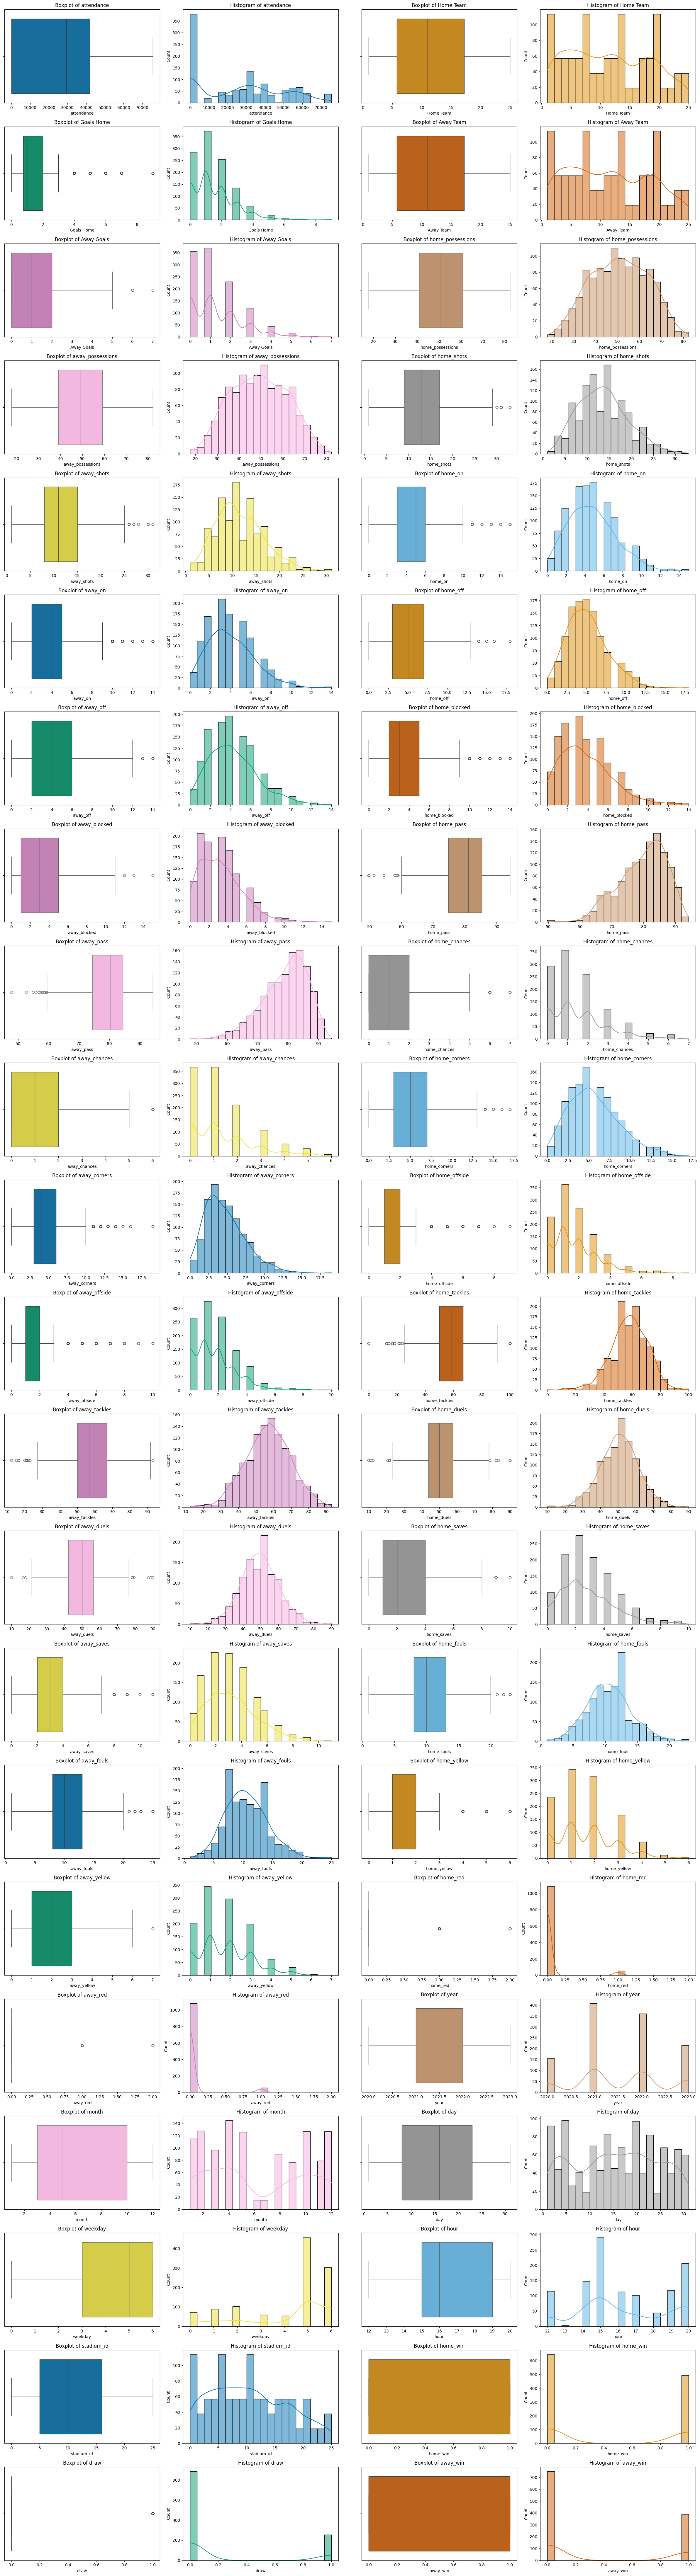

In [ ]:
# Select numeric columns
num_cols = df.select_dtypes(include=['int32', 'int64', 'float64']).columns

# Assign color palette
colors = sns.color_palette('colorblind', n_colors=len(num_cols))

# Each feature uses 2 columns (box + hist) → total cols = 4
ncols = 4
nrows = (len(num_cols) * 2 + ncols - 1) // ncols  # round up

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

plot_idx = 0
for col, color in zip(num_cols, colors):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Boxplot of {col}')
    plot_idx += 1

    # Histogram
    sns.histplot(df[col], bins=20, kde=True, ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Histogram of {col}')
    plot_idx += 1

# Remove unused axes
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Peta Korelasi

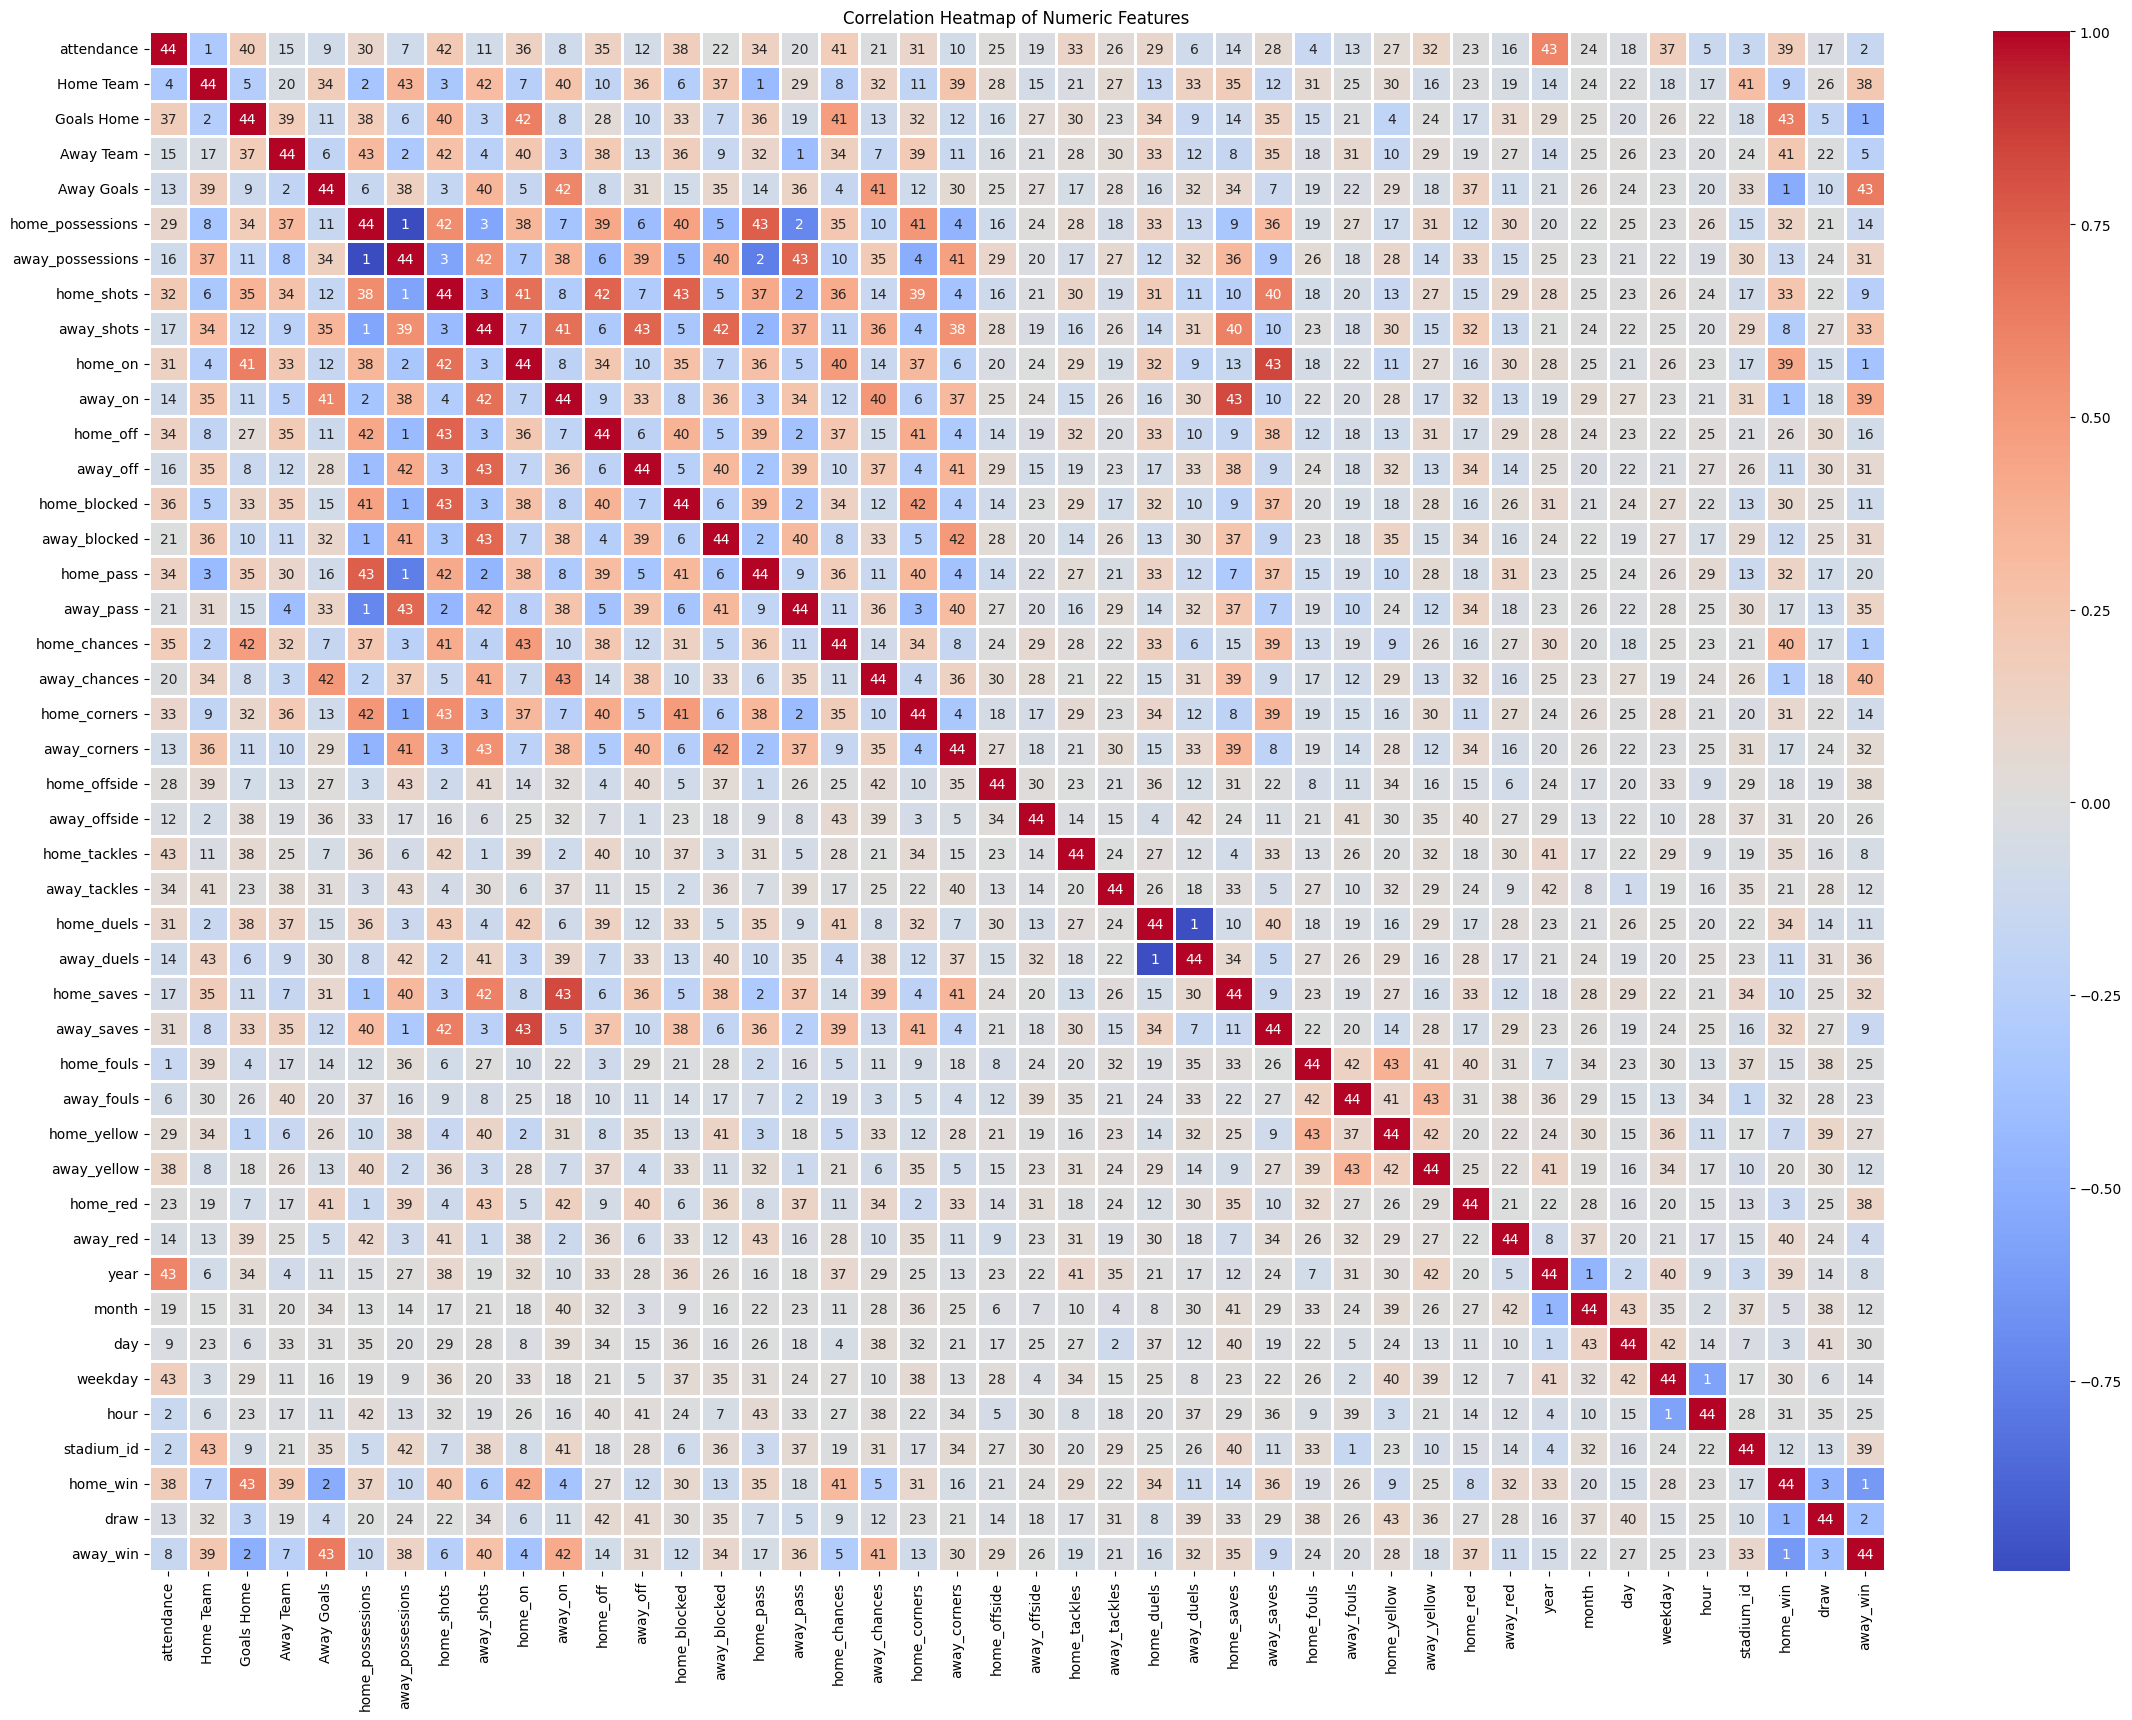

In [ ]:
plt.figure(figsize=(28,20))
corr = df.select_dtypes(include=['float64','int64','int32']).corr()
sns.heatmap(corr, annot=corr.rank(axis='columns'), linewidth=1, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Pasangan

Top correlated feature pairs:
 home_on           away_saves      0.843065
away_on           home_saves      0.833833
home_possessions  home_pass       0.758105
home_shots        home_blocked    0.749903
                  home_off        0.735059
away_shots        away_off        0.729433
                  away_blocked    0.723973
away_possessions  away_pass       0.719612
home_shots        home_on         0.687016
away_shots        away_on         0.686817
dtype: float64
Selected features for pairplot: ['away_shots', 'home_off', 'home_shots', 'away_saves', 'away_off', 'away_pass', 'away_possessions', 'home_on', 'away_blocked', 'home_pass', 'away_on', 'home_saves', 'home_blocked', 'home_possessions']


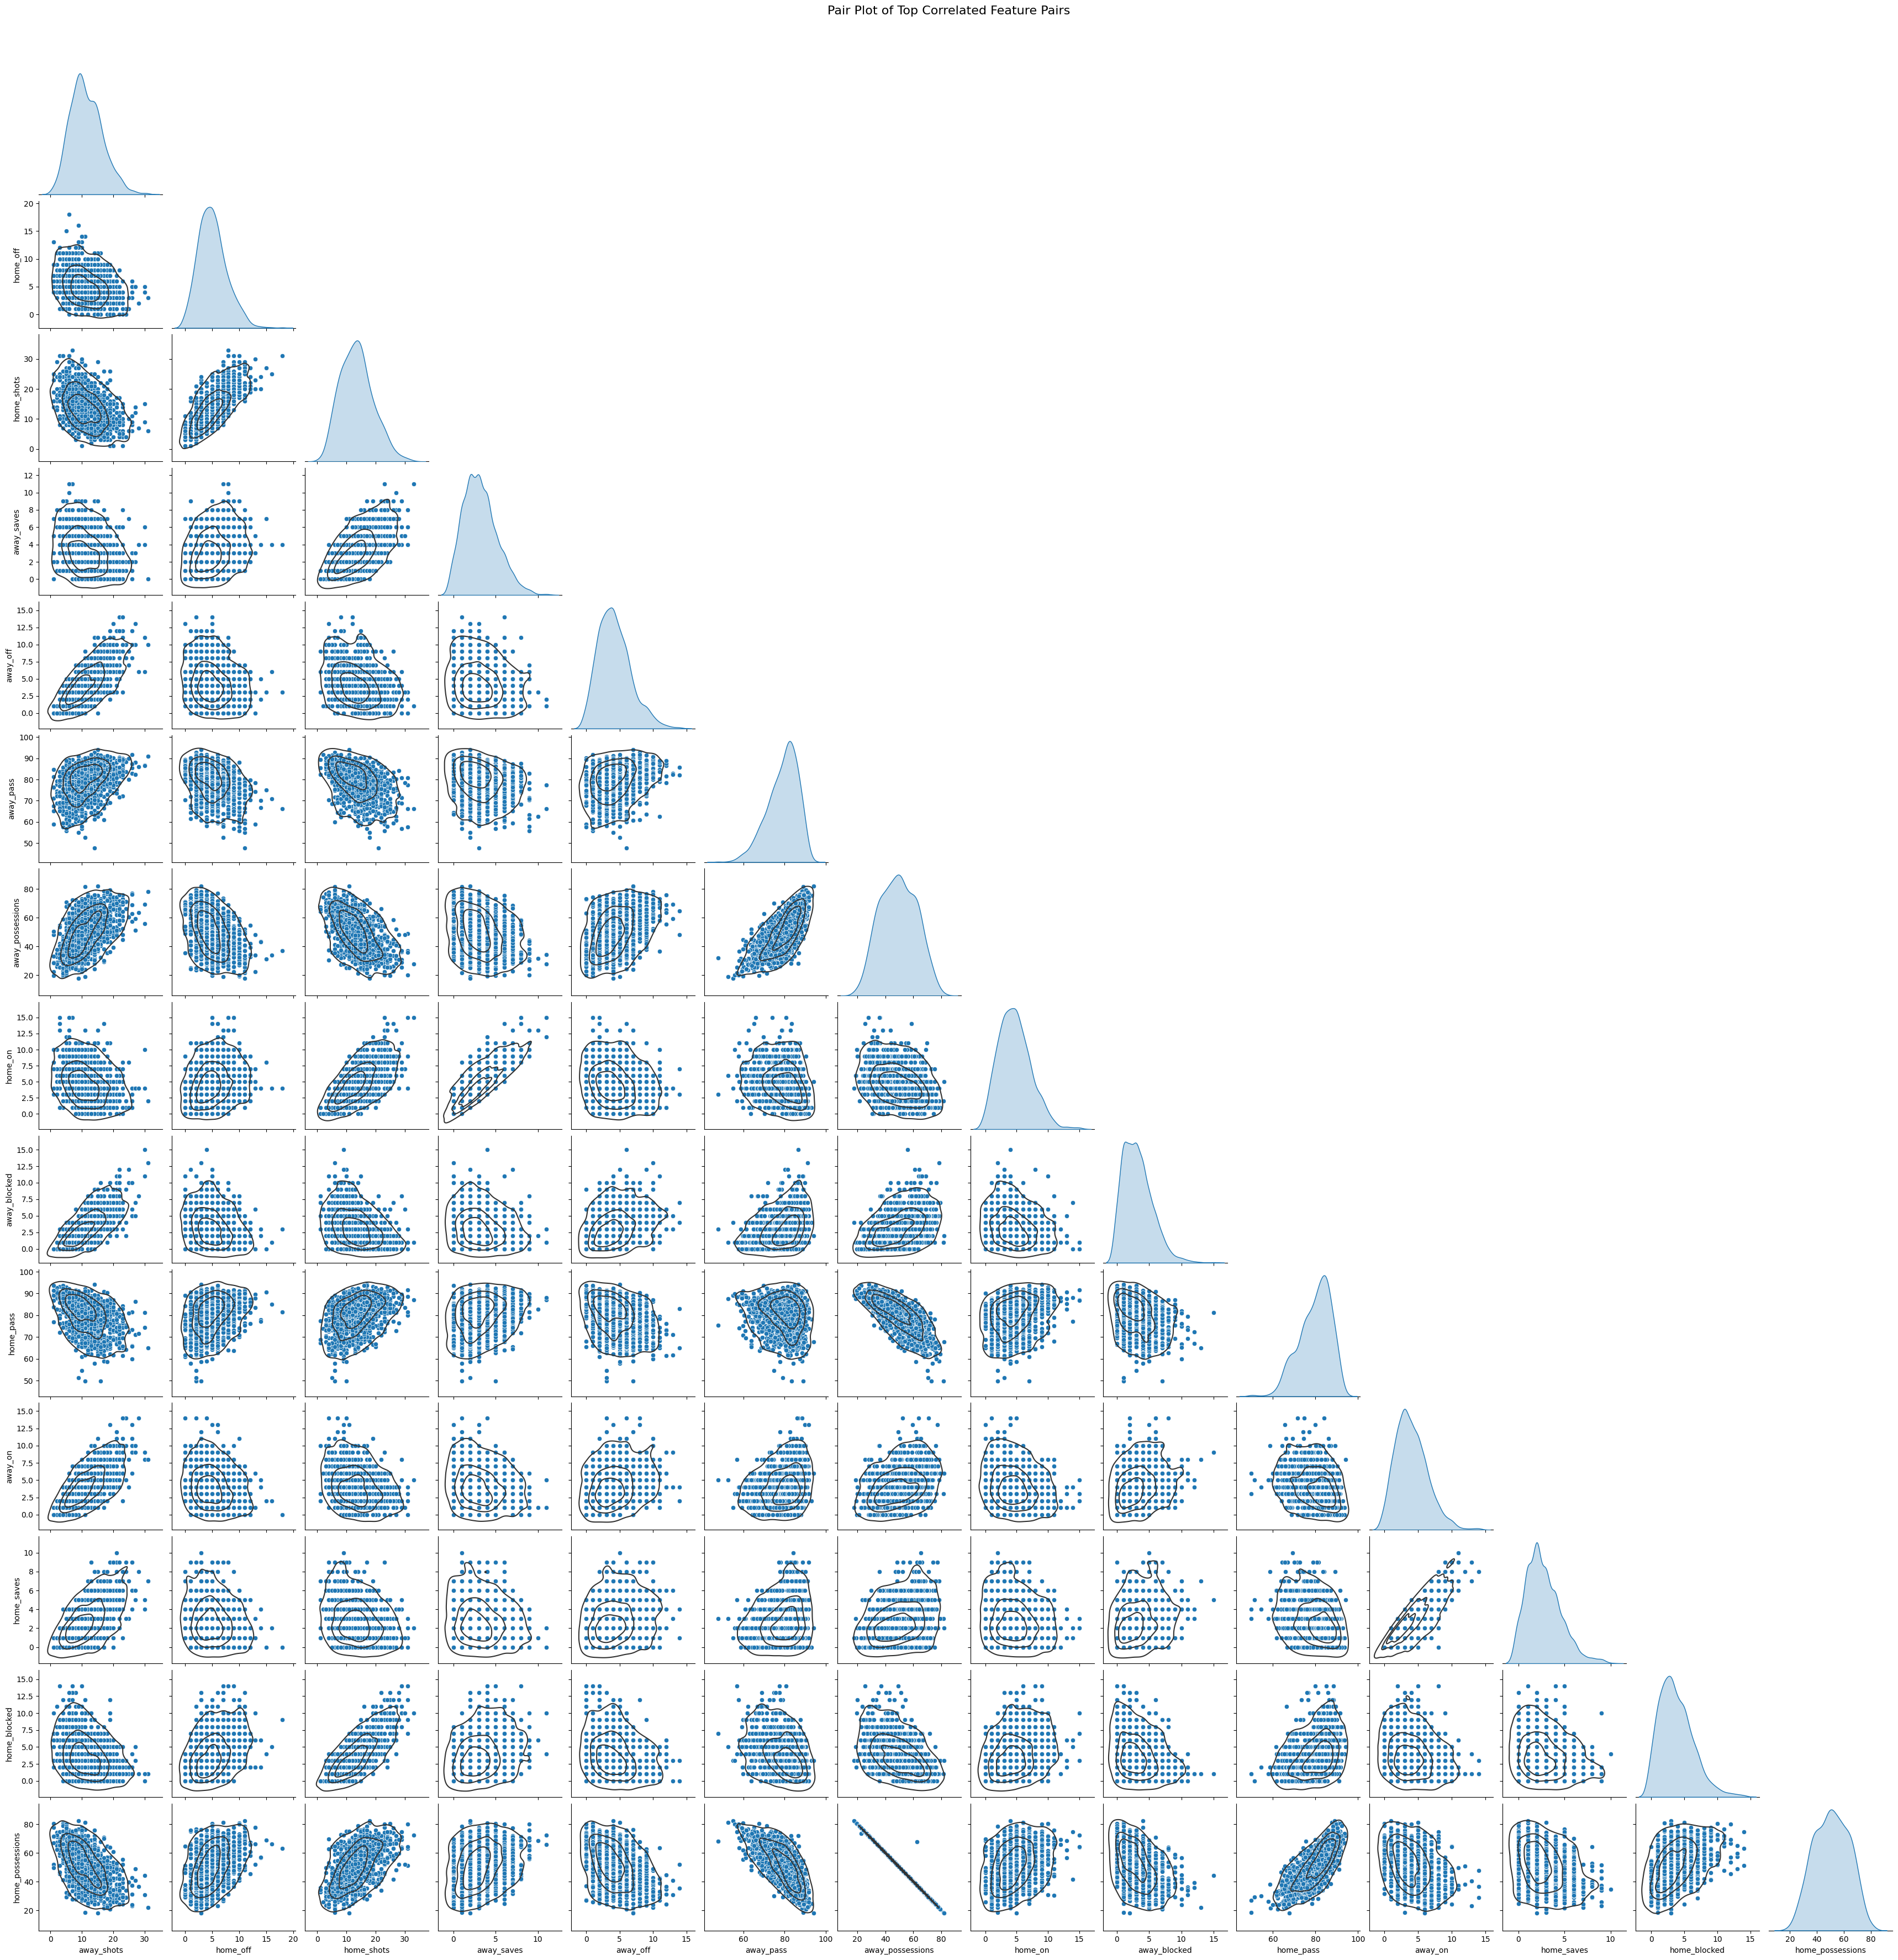

In [ ]:
# --- Step 1: Compute correlation ---
corr = df.select_dtypes(include=['float64', 'int64', 'int32']).corr()

# --- Step 2: Find top N correlated pairs (excluding self-correlation) ---
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .sort_values(ascending=False)
)

top_n = 10  # number of pairs
print("Top correlated feature pairs:\n", corr_pairs.head(top_n))

# --- Step 3: Extract unique feature names from these pairs ---
top_features = list(set([col for pair in corr_pairs.head(top_n).index for col in pair]))
print("Selected features for pairplot:", top_features)

# --- Step 4: Pairplot ---
g = sns.pairplot(df[top_features], diag_kind="kde", corner=True)
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.suptitle('Pair Plot of Top Correlated Feature Pairs', y=1.02, fontsize=16)
plt.show()

## Tren

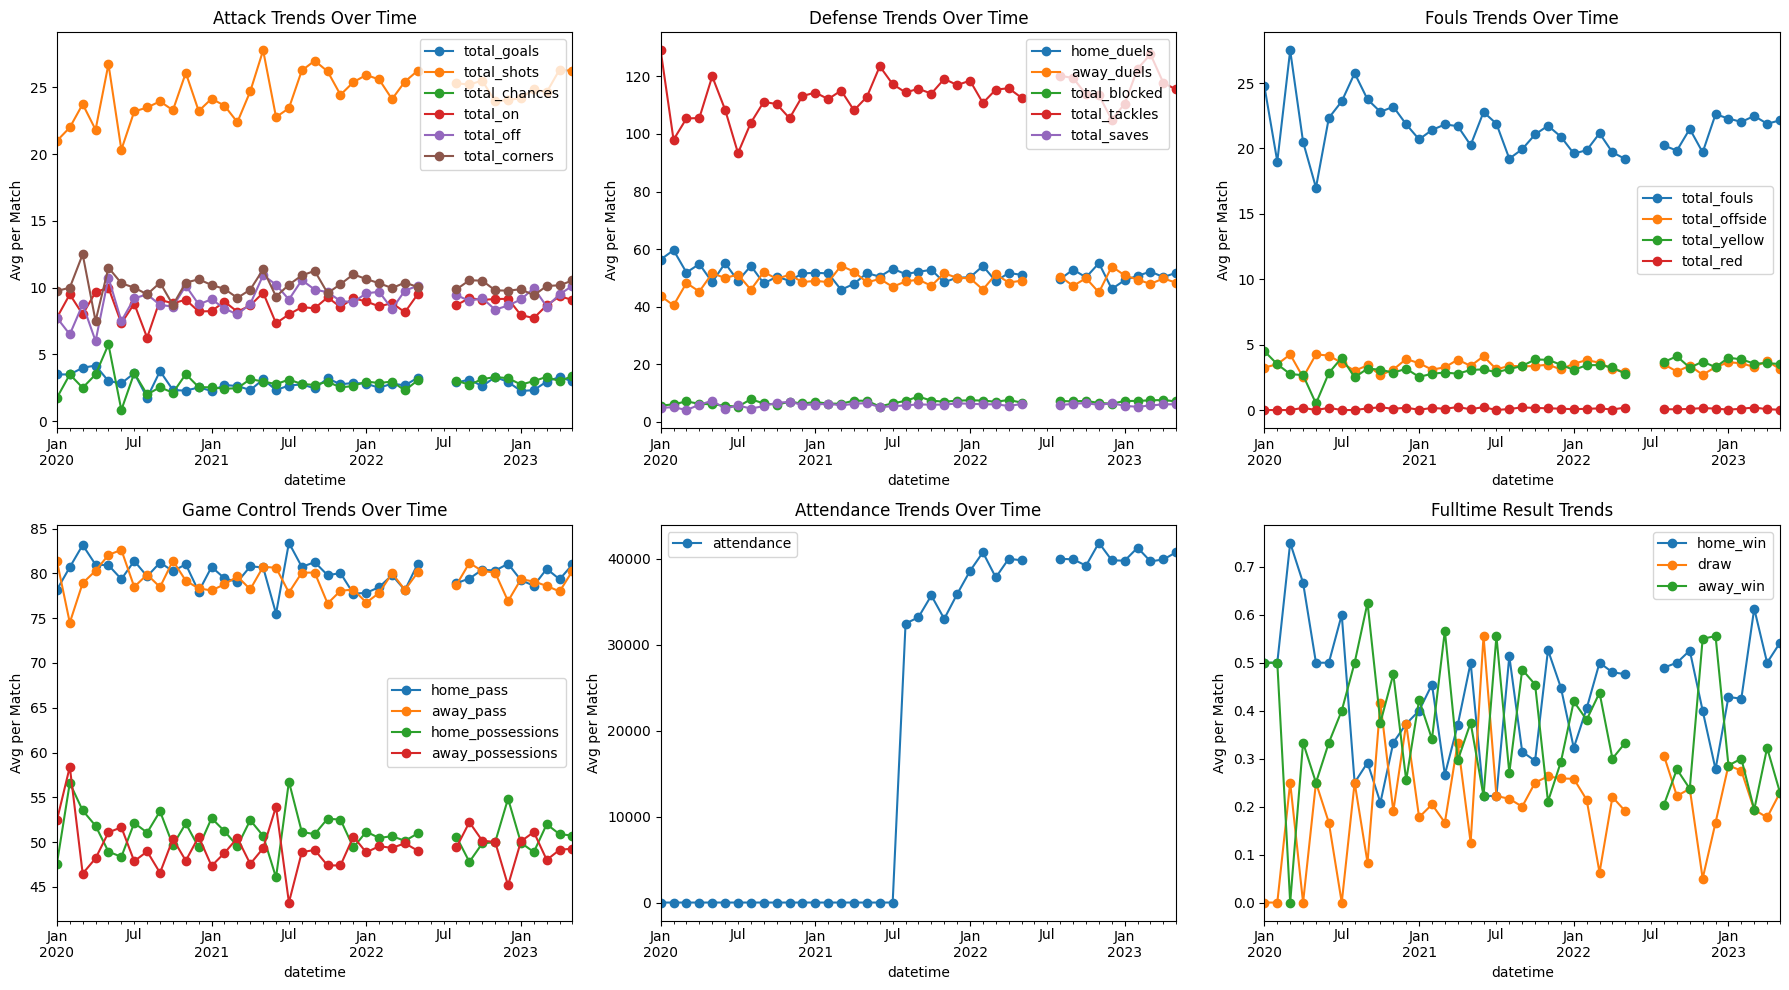

In [ ]:
# --- Aggregated features ---
df = df.copy()
df['total_goals']     = df['Goals Home'] + df['Away Goals']
df['total_shots']     = df['home_shots'] + df['away_shots']
df['total_chances']   = df['home_chances'] + df['away_chances']
df['total_on']        = df['home_on'] + df['away_on']
df['total_off']       = df['home_off'] + df['away_off']
df['total_blocked']   = df['home_blocked'] + df['away_blocked']
df['total_tackles']   = df['home_tackles'] + df['away_tackles']
df['total_saves']     = df['home_saves'] + df['away_saves']
df['total_offside']   = df['home_offside'] + df['away_offside']
df['total_fouls']     = df['home_fouls'] + df['away_fouls']
df['total_yellow']    = df['home_yellow'] + df['away_yellow']
df['total_red']       = df['home_red'] + df['away_red']
df['total_corners']   = df['home_corners'] + df['away_corners']

# --- Resample monthly, numeric only ---
ts = df.set_index('datetime').resample('ME').mean(numeric_only=True)

# --- Feature groups ---
feature_groups = {
    "Attack Trends Over Time":      ['total_goals', 'total_shots', 'total_chances', 'total_on', 'total_off', 'total_corners'],
    "Defense Trends Over Time":     ['home_duels', 'away_duels', 'total_blocked', 'total_tackles', 'total_saves'],
    "Fouls Trends Over Time":       ['total_fouls', 'total_offside', 'total_yellow', 'total_red'],
    "Game Control Trends Over Time":['home_pass', 'away_pass', 'home_possessions', 'away_possessions'],
    "Attendance Trends Over Time":  ['attendance'],
    "Fulltime Result Trends":       ['home_win', 'draw', 'away_win']
}

# --- Grid plots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (title, cols) in zip(axes, feature_groups.items()):
    ts[cols].plot(ax=ax, marker='o')
    ax.set_title(title)
    ax.set_ylabel("Avg per Match")

plt.tight_layout()
plt.show()

## Klasmen
Label | Keterangan | Perhitungan
- | - | -
MP | Tanding | Jumlah pertandingan yang dimainkan (`home` + `away`)
W | Menang | +1 setiap kali tim mencetak gol lebih banyak dari lawan
D | Seri | +1 setiap kali skor imbang
L | Kalah | +1 setiap kali tim kebobolan lebih banyak dari lawan
GF | Gol Dicetak | Total gol yang dicetak tim
GA | Gol Kebobolan | Total gol yang diterima tim
GD | Selisih Gol | `GF - GA`
Pts | Poin | 3 × `W` + 1 × `D`
Shots | Tembakan | Jumlah tembakan tim (`home_shots` + `away_shots`)
GCR | Konversi Gol | `GF / Shots` (jika `Shots` > 0, else 0)
Saves | Penyelamatan | Total saves kiper tim (`home_saves` + `away_saves`)
Avg Poss | Rata-Rata Penguasaan Bola | `(total possessions) / MP`
Yellows | Kartu Kuning | Jumlah kartu kuning (`home_yellow + `away_yellow`)
Reds | Kartu Merah | Jumlah kartu merah (`home_red` + `away_red`)
Corners | Tendangan Penjuru | Total tendangan sudut (`home_corners + away_corners`)


In [ ]:
# Get a list of all unique team IDs
all_teams = pd.concat([df['Home Team'], df['Away Team']]).unique()

# Initialize a dictionary to store the stats for each team
team_stats = {}
for team in all_teams:
    team_stats[team] = {
        'MP': 0, 'W': 0, 'D': 0, 'L': 0,
        'GF': 0, 'GA': 0, 'Pts': 0,
        'Shots': 0, 'Saves': 0, 'Possessions': 0,
        'Yellows': 0, 'Reds': 0, 'Corners': 0,
        'Home Attendance': 0, 'Away Attendance': 0,
        'Home Matches': 0, 'Away Matches': 0
    }

# Iterate over each match to calculate the stats
for _, row in df.iterrows():
    home_team = row['Home Team']
    away_team = row['Away Team']
    home_goals, away_goals = row['Goals Home'], row['Away Goals']
    attendance = row['attendance']  # assumes attendance column exists

    # Update matches played
    team_stats[home_team]['MP'] += 1
    team_stats[away_team]['MP'] += 1

    # Track home & away matches + attendance
    team_stats[home_team]['Home Matches'] += 1
    team_stats[home_team]['Home Attendance'] += attendance
    team_stats[away_team]['Away Matches'] += 1
    team_stats[away_team]['Away Attendance'] += attendance

    # Update goals
    team_stats[home_team]['GF'] += home_goals
    team_stats[home_team]['GA'] += away_goals
    team_stats[away_team]['GF'] += away_goals
    team_stats[away_team]['GA'] += home_goals

    # Shots
    team_stats[home_team]['Shots'] += row['home_shots']
    team_stats[away_team]['Shots'] += row['away_shots']

    # Saves
    team_stats[home_team]['Saves'] += row['home_saves']
    team_stats[away_team]['Saves'] += row['away_saves']

    # Possessions (sum, will average later)
    team_stats[home_team]['Possessions'] += row['home_possessions']
    team_stats[away_team]['Possessions'] += row['away_possessions']

    # Cards
    team_stats[home_team]['Yellows'] += row['home_yellow']
    team_stats[away_team]['Yellows'] += row['away_yellow']
    team_stats[home_team]['Reds'] += row['home_red']
    team_stats[away_team]['Reds'] += row['away_red']

    # Corners
    team_stats[home_team]['Corners'] += row['home_corners']
    team_stats[away_team]['Corners'] += row['away_corners']

    # Win/Draw/Loss + Points
    if home_goals > away_goals:
        team_stats[home_team]['W'] += 1
        team_stats[home_team]['Pts'] += 3
        team_stats[away_team]['L'] += 1
    elif home_goals < away_goals:
        team_stats[away_team]['W'] += 1
        team_stats[away_team]['Pts'] += 3
        team_stats[home_team]['L'] += 1
    else:
        team_stats[home_team]['D'] += 1
        team_stats[away_team]['D'] += 1
        team_stats[home_team]['Pts'] += 1
        team_stats[away_team]['Pts'] += 1

# Convert to DataFrame
league_table = pd.DataFrame.from_dict(team_stats, orient='index')

# Calculate GD
league_table['GD'] = league_table['GF'] - league_table['GA']

# Calculate Shot-to-Goal Conversion Rate
league_table['GCR'] = league_table.apply(
    lambda x: x['GF'] / x['Shots'] if x['Shots'] > 0 else 0, axis=1
)

# Calculate Average Possession
league_table['Avg Poss'] = league_table['Possessions'] / league_table['MP']

# Calculate Average Attendances
league_table['Avg Home Attendance'] = league_table.apply(
    lambda x: x['Home Attendance'] / x['Home Matches'] if x['Home Matches'] > 0 else 0, axis=1
)
league_table['Avg Away Attendance'] = league_table.apply(
    lambda x: x['Away Attendance'] / x['Away Matches'] if x['Away Matches'] > 0 else 0, axis=1
)

# Sort table
league_table.sort_values(by=['Pts', 'GD', 'GF'], ascending=[False, False, False], inplace=True)

# Reset index
league_table.reset_index(inplace=True)
league_table.rename(columns={'index': 'Team ID'}, inplace=True)

# Reorder columns
league_table = league_table[['Team ID','MP','W','D','L','GF','GA','GD','Pts',
                             'Shots','GCR','Saves','Avg Poss',
                             'Yellows','Reds','Corners',
                             'Avg Home Attendance','Avg Away Attendance']]

# Create mapping: Team ID → Stadium (based on first home match found)
team_stadium_map = df.groupby('Home Team')['stadium'].first().to_dict()

# Add Stadium column
league_table['Home Stadium'] = league_table['Team ID'].map(team_stadium_map)

# Reorder columns to place Stadium right after Team ID
cols = league_table.columns.tolist()
cols.insert(1, cols.pop(cols.index('Home Stadium')))
league_table = league_table[cols]

league_table

,Team ID,Home Stadium,MP,W,D,L,GF,GA,GD,Pts,Shots,GCR,Saves,Avg Poss,Yellows,Reds,Corners,Avg Home Attendance,Avg Away Attendance
0,1,Etihad Stadium,114,84,16,14,276,91,185,268,1912,0.144351,190,65.671930,133,4,801,35340.947368,26802.824561
1,5,Anfield,114,67,27,20,238,116,122,228,1942,0.122554,296,62.180702,147,3,781,35404.456140,26245.684211
2,2,Emirates Stadium,114,66,16,32,204,130,74,214,1638,0.124542,291,55.465789,159,9,635,39987.333333,26132.859649
3,3,Old Trafford,114,60,27,27,188,144,44,207,1626,0.115621,329,54.120175,217,5,590,48216.192982,25685.754386
4,8,Tottenham Hotspur Stadium,114,58,19,37,207,148,59,193,1452,0.142562,323,51.144737,195,6,560,39369.368421,26069.105263
5,12,Stamford Bridge,114,51,32,31,172,116,56,185,1634,0.105263,273,60.895614,189,6,678,25937.859649,26838.175439
6,4,"St James' Park, Newcastle",114,44,33,37,158,157,1,165,1417,0.111503,337,43.585088,202,6,591,34538.122807,26370.684211
7,7,Villa Park,114,47,20,47,158,146,12,161,1420,0.111268,347,47.803509,224,7,576,27795.807018,26549.982456
8,14,London Stadium,114,46,23,45,164,153,11,161,1384,0.118497,344,44.321930,141,6,584,40276.543860,25764.578947
9,6,Amex Stadium,114,39,36,39,155,145,10,153,1589,0.097546,271,55.378070,177,7,652,21197.017544,26882.333333
